In [1]:
# Import
import numpy as np
import random as rn
import casadi as ca
import os, json
from scipy.interpolate import splprep, splev
import importlib
import csv
from scipy.interpolate import interp1d
import time
import math

# Import Graphics
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
from IPython.display import HTML
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [8]:
ADSE_MC_Result = {}
ADSE_MC_Result['n_success'] = []
ADSE_MC_Result['d_cost'] = {}
ADSE_MC_Result['a_cost'] = {}
ADSE_MC_Result['payoff'] = {}
ADSE_MC_Result['stopping_criteria'] = {}

for MC_iter in range(10):
    with open('Monte_Carlo_Batch_' + str(MC_iter) + '_SEGame_Monte_Carlo_for_Section_VC.json', 'r') as json_file:
            result = json.load(json_file)

            ADSE_MC_Result['n_success'].append(result['n_success'])
            ADSE_MC_Result['d_cost'][str(MC_iter)] = result['d_cost']
            ADSE_MC_Result['a_cost'][str(MC_iter)] = result['a_cost']
            ADSE_MC_Result['payoff'][str(MC_iter)] = result['payoff']
            ADSE_MC_Result['stopping_criteria'][str(MC_iter)] = result['stopping_criteria']

In [15]:
# Exact initial and final values of defender cost

defender_cost_init_list = []
defender_cost_fin_list = []

for MC_iter in range(10):
    for i in range(len(ADSE_MC_Result['d_cost'][str(MC_iter)])):
        defender_cost_init_list.append(ADSE_MC_Result['d_cost'][str(MC_iter)][str(i)][0])
        defender_cost_fin_list.append(ADSE_MC_Result['d_cost'][str(MC_iter)][str(i)][-1])

# Exact initial and final values of defender cost

attacker_cost_init_list = []
attacker_cost_fin_list = []

for MC_iter in range(10):
    for i in range(len(ADSE_MC_Result['a_cost'][str(MC_iter)])):
        attacker_cost_init_list.append(ADSE_MC_Result['a_cost'][str(MC_iter)][str(i)][0])
        attacker_cost_fin_list.append(ADSE_MC_Result['a_cost'][str(MC_iter)][str(i)][-1])

-84.48878890468715
23.75510751848375
66.28958522967086
43.38414583211825


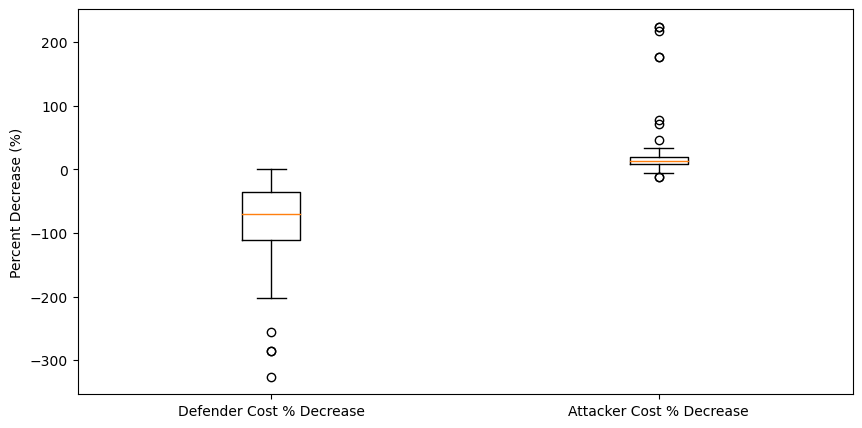

In [37]:
# Compute percent-decrease in defender and attacker cost

defender_cost_percent_decrease_list = []
attacker_cost_percent_decrease_list = []

for i in range(len(defender_cost_fin_list)):
    defender_cost_percent_decrease_list.append((defender_cost_init_list[i] - defender_cost_fin_list[i]) / defender_cost_init_list[i] * 10)

for i in range(len(attacker_cost_fin_list)):
    attacker_cost_percent_decrease_list.append((attacker_cost_init_list[i] - attacker_cost_fin_list[i]) / attacker_cost_init_list[i] * -100)

print(np.mean(defender_cost_percent_decrease_list))
print(np.mean(attacker_cost_percent_decrease_list))
print(np.std(defender_cost_percent_decrease_list))
print(np.std(attacker_cost_percent_decrease_list))

# Plot box-whisker plot of percent-decrease in defender and attacker cost
plt.figure(figsize=(10, 5))
plt.boxplot([defender_cost_percent_decrease_list, attacker_cost_percent_decrease_list],
            labels=['Defender Cost % Decrease', 'Attacker Cost % Decrease'])
plt.ylabel('Percent Decrease (%)')
plt.savefig('Cost_Percent_Decrease_Boxplot.png')